# Three ways to cut the seed template, ranked by `chromatin_od` -- default 51 px vs. `gray_inverted` Otsu vs. `hematoxylin_od` Otsu

**Question.** With everything else fixed at the production configuration and candidates ranked by
`chromatin_od`, how does precision in the top 10, 20 and 30 candidates change across three ways of
building the search template from **the same click**?

| condition | template size | template centre | what it is |
|---|---|---|---|
| `default_51` | 51 px (`tm.BASE_SIZE`, the MIDOG++ annotation box) | the click | untightened -- `FSConfig.base_size`'s default, no Otsu step |
| `gray_bbox` | Otsu component's longer side, on `gray_inverted` | component's bbox centre | `ss.tightened_template_box` -- what `build_seed` does in production today (D8) |
| `hem_bbox` | Otsu component's longer side, on `hematoxylin_od` | component's bbox centre | the same function, fed the search channel instead |

**Only the template's size and centre change between conditions.** The search channel is
`hematoxylin_od` (D3) for all three, and so is the `chromatin_od` statistic (`od51`, a fixed 51 px
window regardless of template size). "Default 51" is a template geometry, not a channel.

**Experiment type** (carried over from `production_seed_precision_at_k_chromatin_hem_bbox.ipynb`):
a within-ROI paired comparison. One click per ROI, drawn once, shared by every condition; each
condition then runs its own search from that click; all conditions are scored against the same
`gt_eval` (the click's own annotation removed). The ROI is the paired unit (D5).

**The click gate.** A drawn annotation is accepted only if *every* condition can build a template
from it: `tightened_template_box` must succeed on both `gray_inverted` and `hematoxylin_od` (the D8
containment gate: the click's own pixel must lie inside the accepted component), and each condition's rotation-safe patch must be readable
at its own template centre. `default_51` has no Otsu gate of its own -- its only requirement is
readability at the click, which `border_filter` already guarantees -- so this is the same predicate
the reference notebook drew under, on the same RNG stream. Gate 1 below checks that the 14 clicks
come out identical. One consequence to keep in mind: `default_51` is measured here on clicks that
both Otsu gates accept, not on its own unconditional draw.

**The pipeline is the shipping entry point**, `production.run_production_pipeline(rgb, seed, mpp,
rank_key="chromatin_od")`, not an inline copy of it: `TM_CCOEFF` (D1), no tissue mask (D2),
`hematoxylin_od` (D3), deep floor `z = -1.5`, `MAX_PEAKS = 100` before NMS (D9), NMS radius = match
radius = 7.5 um (D7), self-hit removal (5 px) at the template centre (D8 cost 1), ground truth keyed
to the click (D8 cost 3). The reference notebook ran the same steps inline; Gate 2 checks the two
agree to the integer on the two conditions they share.

**Scope.**
- 14 ROIs in `images/extra_valid` (2 per tumour domain x 7), one click each (`seed_index = 0`).
- One ranking axis, `chromatin_od`. That follows `PRODUCTION_PIPELINE_CLEANUP.md`'s working
  assumption, not `DECISIONS.md` D5 (which still names `tm_score`); nothing here carries over to
  `tm_score`.
- K = 10, 20, 30 only -- the budgets D9's `MAX_PEAKS = 100` was validated through. D9 validated it
  with `tm_score` ranking, not `chromatin_od`.
- **Ceiling.** The Otsu window is 51 px, so a tightened box can never be larger than `default_51`.
  Where `gray_bbox` already reaches 51, the two differ only in where the template is centred.

In [1]:
import gc
import itertools
import os
import sys
import time

import cv2
import numpy as np
import pandas as pd

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import production as prod
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 220)

NB_T0 = time.time()

IMAGES_DIR = '../images/extra_valid'
DB_PATH = '../databases/MIDOG++.json'
SEED_INDEX = 0                      # one click per ROI, RNG stream [SEED_INDEX, image_id]

# condition -> the channel its Otsu tightening runs on; None = no tightening, 51 px box on the click.
CONDITIONS = {'default_51': None, 'gray_bbox': 'gray_inverted', 'hem_bbox': 'hematoxylin_od'}
# (a, b) -> every delta below is a minus b. default_51 is the reference condition; hem - gray is
# kept for continuity with the reference notebook.
PAIRS = [('gray_bbox', 'default_51'), ('hem_bbox', 'default_51'), ('hem_bbox', 'gray_bbox')]

RANK_KEY = 'chromatin_od'
BUDGETS = (10, 20, 30)

DEFAULT_BASE_SIZE = tm.BASE_SIZE    # 51
OTSU_WINDOW = tm.BASE_SIZE          # 51 -- a tightened box can never exceed this
PATCH_SIZE = tm.PATCH_SIZE          # 73, rotation-safe read around a template centre
BORDER = PATCH_SIZE // 2            # 36

# The production settings are read from midog_utils.production rather than restated here, then
# checked against the values the reference notebook ran with -- so a drift in either fails loudly.
REFERENCE_CONFIG = dict(CHANNEL='hematoxylin_od', TM_METHOD=cv2.TM_CCOEFF, PEAK_MIN_DISTANCE=7, SELF_HIT_RADIUS=5.0, DEEP_FLOOR_Z=-1.5, MAX_PEAKS=100, OD_WINDOW=51)
CONFIG_DRIFT = pd.DataFrame([dict(setting=k, production_py=getattr(prod, k), reference_notebook=v, match=getattr(prod, k) == v) for k, v in REFERENCE_CONFIG.items()])
print(CONFIG_DRIFT.to_string(index=False))
assert CONFIG_DRIFT['match'].all(), 'midog_utils.production no longer matches the configuration the reference notebook ran at'
assert ev.MIDOG_RADIUS_UM == 7.5, 'D7: NMS radius = match radius = 7.5 um'
MAX_PEAKS = prod.MAX_PEAKS

# Reference run, for the reproduction gates: the clicks its Gate 1 confirmed, and its raw CSV.
REF_SEED_ANN_IDS = {'013.tiff': 249, '094.tiff': 2512, '201.tiff': 4457, '233.tiff': 5761, '245.tiff': 6317, '246.tiff': 6548, '300.tiff': 14499, '301.tiff': 14969, '402.tiff': 20254, '403.tiff': 20356, '459.tiff': 22441, '460.tiff': 22577, '529.tiff': 24918, '548.tiff': 25804}
REF_RAW = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_raw.csv'

OUT_STEM = '../results/precision_at_k_14roi_prodseed_chromatin_bbox3way'
OUT_PER_ROI = f'{OUT_STEM}_per_roi.csv'
OUT_SUMMARY = f'{OUT_STEM}_summary.csv'
OUT_BY_DOMAIN = f'{OUT_STEM}_by_domain.csv'
OUT_DELTA_PER_ROI = f'{OUT_STEM}_delta_per_roi.csv'
OUT_DELTA_STATS = f'{OUT_STEM}_delta_stats.csv'
OUT_TOP = f'{OUT_STEM}_top{max(BUDGETS)}.csv'
OUT_VERIF = f'{OUT_STEM}_verification.csv'
OUT_CONTESTED = f'{OUT_STEM}_contested_sensitivity.csv'
FIG_STEM = 'bbox3way'

print(f'\n14 ROIs x 1 joint click x {len(CONDITIONS)} conditions, ranked by {RANK_KEY}, K = {BUDGETS}, MAX_PEAKS = {MAX_PEAKS}')

          setting  production_py reference_notebook  match
          CHANNEL hematoxylin_od     hematoxylin_od   True
        TM_METHOD              4                  4   True
PEAK_MIN_DISTANCE              7                  7   True
  SELF_HIT_RADIUS            5.0                5.0   True
     DEEP_FLOOR_Z           -1.5               -1.5   True
        MAX_PEAKS            100                100   True
        OD_WINDOW             51                 51   True

14 ROIs x 1 joint click x 3 conditions, ranked by chromatin_od, K = (10, 20, 30), MAX_PEAKS = 100


## The click and the run

Per ROI: convert `gray_inverted` and `hematoxylin_od` once, build the seed pool the way `build_seed`
does (`agreement_pool`, then `border_filter` at 36 px), and walk the `[0, image_id]` RNG stream until
an annotation passes the joint gate. Each condition's `(base_size, template_xy)` becomes a
`seed_selection.Seed` and goes through `run_production_pipeline` unchanged.

Scoring: `evaluate.bucket_detections` greedily matches the full ranked list to `gt_eval` in rank
order, and TP@K counts `human_correct_label` in the top K. Because matching goes best-rank-first,
which annotations the top K claim never depends on anything ranked below K, so this is the same
count as matching the top K on its own.

In [2]:
def roi_files(images_dir=IMAGES_DIR):
    """
        The ROI TIFFs on disk, sorted by name.

        images_dir (str): directory holding the ROI TIFFs.

        Returns list[str]: file names ending in .tiff.
    """
    return sorted(f for f in os.listdir(images_dir) if f.endswith('.tiff'))


def template_spec(condition, channels, cx, cy):
    """
        The template size and centre one condition cuts for one click.

        condition (str): a key of CONDITIONS.
        channels (dict): channel name -> this ROI's converted single-channel image.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns tuple[int, float, float] or None: (base_size, template x, template y), or None if the Otsu gate refuses the click or the rotation-safe patch can't be read at the template centre.
    """
    tighten_channel = CONDITIONS[condition]
    spec = (DEFAULT_BASE_SIZE, cx, cy) if tighten_channel is None else ss.tightened_template_box(channels[tighten_channel], cx, cy, otsu_window=OTSU_WINDOW)
    if spec is None or tm.read_padded_patch(channels['hematoxylin_od'], spec[1], spec[2], PATCH_SIZE) is None:
        return None
    return int(spec[0]), float(spec[1]), float(spec[2])


def draw_joint_click(pool, rng, channels):
    """
        Draw one click every condition can build a template from, redrawing on the same RNG stream after a refusal.

        pool (pd.DataFrame): agreement-tier, border-filtered mitotic annotations.
        rng (np.random.Generator): this ROI's [SEED_INDEX, image_id] stream.
        channels (dict): channel name -> this ROI's converted single-channel image.

        Returns tuple[pd.Series, dict, list[str]]: the accepted annotation, condition -> (base_size, x, y), and one "ann_id:refusing+conditions" entry per refused draw, in draw order.
    """
    working, refusals = pool.copy(), []
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        specs = {condition: template_spec(condition, channels, float(row['cx']), float(row['cy'])) for condition in CONDITIONS}
        if all(spec is not None for spec in specs.values()):
            return row, specs, refusals
        refusals.append(f"{int(row['ann_id'])}:{'+'.join(c for c, spec in specs.items() if spec is None)}")
        working = working.drop(working.index[idx])
    raise ValueError('seed pool exhausted -- no annotation passed every condition')


def score_top_k(detections, gt_eval, match_radius):
    """
        Match a ranked detection list to ground truth and count true positives in each top-K.

        detections (pd.DataFrame): ranked detections, best first.
        gt_eval (pd.DataFrame): ground truth with the click's own annotation removed.
        match_radius (float): match radius in pixels.

        Returns tuple[pd.DataFrame, dict]: the detections with match buckets added, and K -> true positives in the top K.
    """
    det_out, _ = ev.bucket_detections(detections, gt_eval, match_radius)
    hit = (det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).to_numpy()
    return det_out, {k: int(hit[:k].sum()) for k in BUDGETS}


def run_roi(fn, image_id, domain, annotations):
    """
        Draw one joint click on one ROI and run the production pipeline once per condition from it.

        fn (str): ROI file name.
        image_id (int): the ROI's MIDOG++ image id; seeds the RNG stream.
        domain (str): the ROI's tumour domain.
        annotations (pd.DataFrame): the full MIDOG++ annotation table.

        Returns tuple[list[dict], dict, list[pd.DataFrame]]: one result row per condition, this ROI's click record, and each condition's top-max(BUDGETS) scored detections.
    """
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    channels = {name: ch.to_channel(rgb, name) for name in ('gray_inverted', 'hematoxylin_od')}

    gt = ds.image_annotations(annotations, fn)
    pool, flagged = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    n_agreement = len(pool)
    pool = ss.border_filter(pool, BORDER, rgb.shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    ann, specs, refusals = draw_joint_click(pool, rng, channels)
    n_retries = len(refusals)
    del channels
    gc.collect()

    click_xy = (float(ann['cx']), float(ann['cy']))
    seed_ann_id = int(ann['ann_id'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)  # D8 cost 3: ground truth stays keyed to the click
    n_gt = int((gt_eval['category_id'] == ds.MITOTIC).sum())
    match_radius = ev.radius_px(mpp)

    rows, tops = [], []
    for condition, (base_size, tx, ty) in specs.items():
        offset = float(np.hypot(tx - click_xy[0], ty - click_xy[1]))
        seed = ss.Seed(ann_id=seed_ann_id, click_xy=click_xy, template_xy=(tx, ty), base_size=base_size, recentred=CONDITIONS[condition] is not None, offset_px=offset, n_retries=n_retries, agreement_flagged=bool(flagged), n_agreement_pool=n_agreement, n_after_border=len(pool))
        t0 = time.time()
        detections, info = prod.run_production_pipeline(rgb, seed, mpp, rank_key=RANK_KEY)
        det_out, tp = score_top_k(detections, gt_eval, match_radius)

        # the seed annulus: anything left within one match radius of the click (the annotation removed from gt_eval)
        d_click = np.hypot(det_out['cx'] - click_xy[0], det_out['cy'] - click_xy[1])
        near = det_out[d_click <= match_radius]
        od = det_out['od'].to_numpy()
        rows.append(dict(file_name=fn, domain=domain, image_id=image_id, condition=condition, seed_ann_id=seed_ann_id, base_size=base_size, tpl_cx=tx, tpl_cy=ty, tpl_offset_px=round(offset, 3), n_gt_mitotic=n_gt, n_peaks=int(info['n_peaks']), max_peaks_binding=bool(info['max_peaks_binding']), n_detections=int(info['n_detections']), n_self_hits=int(info['n_self_hits']), n_near_click=len(near), near_click_ranks=';'.join(str(int(r)) for r in near['rank']), near_click_buckets=';'.join(near['bucket']), od_nan=int(np.isnan(od).sum()), od_descending=bool(np.all(np.diff(od) <= 0)), match_radius_px=match_radius, mpp=mpp, t_pipeline_s=round(time.time() - t0, 1), **{f'tp_at_{k}': tp[k] for k in BUDGETS}))
        tops.append(det_out.head(max(BUDGETS)).assign(file_name=fn, condition=condition))
        print(f"  [{fn}/{condition:10s}] base={base_size:2d} offset={offset:5.2f}px n_detections={info['n_detections']:3d} tp@{BUDGETS}={tuple(tp.values())} [{rows[-1]['t_pipeline_s']:.1f}s]", flush=True)

    del rgb
    gc.collect()
    click = dict(file_name=fn, domain=domain, image_id=image_id, seed_ann_id=seed_ann_id, click_cx=click_xy[0], click_cy=click_xy[1], n_retries=n_retries, refused_draws=';'.join(refusals), contested_seed_tier=bool(flagged), n_gt_mitotic=n_gt)
    return rows, click, tops


print(f'{len(roi_files())} ROIs on disk in {IMAGES_DIR}/')

14 ROIs on disk in ../images/extra_valid/


In [3]:
images, annotations = ds.load_annotations(DB_PATH)
# the two dataset conventions this notebook relies on (formerly dataset.check_invariants, removed by the production cleanup)
assert ((annotations['w'] == ds.BOX_SIZE) & (annotations['h'] == ds.BOX_SIZE)).all(), f'an annotation box is not {ds.BOX_SIZE}x{ds.BOX_SIZE}'
assert set(annotations['category_id'].unique()) <= {ds.MITOTIC, ds.LOOKALIKE}, 'unexpected annotation category id'
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

files = roi_files()
missing = sorted(set(files) - set(meta_ix.index))
assert not missing, f'.tiff on disk absent from the annotation DB: {missing}'
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

t_run = time.time()
result_rows, click_rows, top_frames = [], [], []
for fn in files:
    rows, click, tops = run_roi(fn, int(meta_ix.loc[fn, 'image_id']), meta_ix.loc[fn, 'tumor_type'], annotations)
    result_rows.extend(rows)
    click_rows.append(click)
    top_frames.extend(tops)
    print(f"[{fn}] {click['domain']:32s} seed_ann_id={click['seed_ann_id']} n_retries={click['n_retries']} n_gt={click['n_gt_mitotic']}", flush=True)

RESULTS = pd.DataFrame(result_rows)
CLICKS = pd.DataFrame(click_rows).set_index('file_name')
TOP = pd.concat(top_frames, ignore_index=True)
TOP.to_csv(OUT_TOP, index=False)

ROI_ORDER = CLICKS.reset_index().sort_values(['domain', 'file_name'])['file_name'].tolist()
print(f'\n{len(files)} ROIs x {len(CONDITIONS)} conditions = {len(RESULTS)} pipeline runs in {time.time() - t_run:.0f}s; top-{max(BUDGETS)} lists -> {OUT_TOP}')

  [013.tiff/default_51] base=51 offset= 0.00px n_detections= 99 tp@(10, 20, 30)=(6, 8, 9) [4.2s]


  [013.tiff/gray_bbox ] base=39 offset= 2.50px n_detections= 97 tp@(10, 20, 30)=(6, 8, 9) [3.7s]


  [013.tiff/hem_bbox  ] base=39 offset= 1.12px n_detections= 98 tp@(10, 20, 30)=(6, 9, 10) [3.7s]


[013.tiff] human breast cancer              seed_ann_id=249 n_retries=1 n_gt=17


  [094.tiff/default_51] base=51 offset= 0.00px n_detections= 99 tp@(10, 20, 30)=(5, 15, 21) [4.0s]


...

  [548.tiff/default_51] base=51 offset= 0.00px n_detections= 99 tp@(10, 20, 30)=(9, 15, 22) [5.7s]


  [548.tiff/gray_bbox ] base=29 offset= 2.55px n_detections= 98 tp@(10, 20, 30)=(8, 13, 21) [4.9s]


  [548.tiff/hem_bbox  ] base=27 offset= 3.04px n_detections= 98 tp@(10, 20, 30)=(8, 13, 21) [4.5s]


[548.tiff] human melanoma                   seed_ann_id=25804 n_retries=0 n_gt=238



14 ROIs x 3 conditions = 42 pipeline runs in 210s; top-30 lists -> ../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_top30.csv


## Checks before any table

Per (ROI, condition) run:
- **D9 cap binds**: `n_peaks == MAX_PEAKS`. At 100 the cap is meant to truncate, so this checks it did.
- **Budget delivered**: the post-NMS list has at least 30 candidates, so every K is a full K.
- **Ranking is what it claims**: no NaN `od`, and the list really is `od`-descending.
- **Seed annulus empty**: no surviving candidate within one match radius of the click. The clicked
  annotation is removed from `gt_eval`, so a candidate there that the 5 px self-hit filter missed
  would count as a false positive for rediscovering the click. Measured from the click (the
  annotation that was removed), not the template centre.
- **One click per ROI**: `seed_ann_id` and `n_gt_mitotic` identical across the three conditions.

The NMS radius equals the 7.5 um match radius (D7) by construction: `production.py` sets it to
`evaluate.radius_px(mpp)`. Its own `check_nms_radius` compares that value against the same formula,
so it cannot fail and is not evidence of anything.

In [4]:
per_roi = RESULTS.groupby('file_name')
checks = [
    ('max_peaks_binds', RESULTS['n_peaks'] == MAX_PEAKS),
    ('budget_delivered', RESULTS['n_detections'] >= max(BUDGETS)),
    ('od_no_nan', RESULTS['od_nan'] == 0),
    ('od_descending', RESULTS['od_descending']),
    ('seed_annulus_empty', RESULTS['n_near_click'] == 0),
]
VERIF = pd.concat([pd.DataFrame(dict(check=name, file_name=RESULTS['file_name'], condition=RESULTS['condition'], passed=passed.to_numpy())) for name, passed in checks], ignore_index=True)
same_click = (per_roi['seed_ann_id'].nunique() == 1) & (per_roi['n_gt_mitotic'].nunique() == 1)
VERIF = pd.concat([VERIF, pd.DataFrame(dict(check='one_click_per_roi', file_name=same_click.index, condition='ALL', passed=same_click.to_numpy()))], ignore_index=True)

print(VERIF.groupby('check')['passed'].agg(passed='sum', total='size').to_string())
if not (RESULTS['n_near_click'] == 0).all():
    print('\nseed-annulus survivors (rank within the chromatin_od list, and what they matched):')
    print(RESULTS.loc[RESULTS['n_near_click'] > 0, ['file_name', 'condition', 'base_size', 'n_near_click', 'near_click_ranks', 'near_click_buckets']].to_string(index=False))
print(f"\nself-hits removed per run: {RESULTS['n_self_hits'].value_counts().sort_index().to_dict()}  (0 = the template's own peak did not make the top {MAX_PEAKS})")

VERIF.to_csv(OUT_VERIF, index=False)
assert VERIF['passed'].all(), f'a pipeline check failed -- see {OUT_VERIF}'

                    passed  total
check                            
budget_delivered        42     42
max_peaks_binds         42     42
od_descending           42     42
od_no_nan               42     42
one_click_per_roi       14     14
seed_annulus_empty      42     42

self-hits removed per run: {1: 42}  (0 = the template's own peak did not make the top 100)


## Reproduction gates

**Gate 1 -- the clicks.** The joint gate adds nothing for `default_51`, so the draw should land on
the same 14 annotations the reference notebook's Gate 1 confirmed. (This is a hard-coded snapshot of
that notebook's output, used as a tripwire.)

**Gate 2 -- the two Otsu conditions reproduce the reference run.** `gray_bbox` and `hem_bbox`
recompute what `production_seed_precision_at_k_chromatin_hem_bbox.ipynb` computed inline for its
`chromatin_od` arm. Checked against its raw CSV: `base_size`, template centre, post-NMS list length,
and TP at K = 10/20/30 must match exactly. That also shows the production entry point and the
reference notebook's inline pipeline are the same computation.

**Gate 3 -- identical template, identical list.** Where `gray_bbox`'s component already fills the
51 px window *and* its bbox centre is the click, its template is the same pixels as `default_51`'s.
Both runs must then return the same top-30 coordinates and the same TP counts. This tests the
`default_51` path directly.

In [5]:
# Gate 1 -- the 14 clicks
gate1 = CLICKS['seed_ann_id'].rename('seed_ann_id').to_frame().assign(reference=pd.Series(REF_SEED_ANN_IDS))
gate1['match'] = gate1['seed_ann_id'] == gate1['reference']
print(f"Gate 1: joint click matches the reference notebook's click on {int(gate1['match'].sum())}/{len(gate1)} ROIs")

# Gate 2 -- gray_bbox / hem_bbox against the reference raw CSV
assert os.path.exists(REF_RAW), f'{REF_RAW} is missing -- Gate 2 cannot run'
ref = pd.read_csv(REF_RAW)
ref = ref[(ref['arm'] == RANK_KEY) & ref['budget'].isin(BUDGETS)]
ref = ref.pivot_table(index=['file_name', 'condition', 'base_size', 'tpl_cx', 'tpl_cy', 'n_detections'], columns='budget', values='tp_at_budget').reset_index()
ref.columns = [f'tp_at_{c}' if isinstance(c, (int, np.integer)) else c for c in ref.columns]
cols = ['base_size', 'tpl_cx', 'tpl_cy', 'n_detections'] + [f'tp_at_{k}' for k in BUDGETS]
gate2 = RESULTS[RESULTS['condition'].isin(['gray_bbox', 'hem_bbox'])].merge(ref, on=['file_name', 'condition'], how='left', suffixes=('', '_ref'), indicator=True)
assert (gate2['_merge'] == 'both').all(), 'a (ROI, condition) row is absent from the reference CSV'
gate2_match = pd.DataFrame({c: np.isclose(gate2[c].astype(float), gate2[f'{c}_ref'].astype(float), rtol=0, atol=1e-9) for c in cols})
gate2['all_match'] = gate2_match.all(axis=1)
print(f"Gate 2: {int(gate2['all_match'].sum())}/{len(gate2)} (ROI, condition) rows reproduce the reference exactly on {cols}")
if not gate2['all_match'].all():
    print(gate2.loc[~gate2['all_match'], ['file_name', 'condition'] + [x for c in cols for x in (c, f'{c}_ref')]].to_string(index=False))

# Gate 3 -- identical template -> identical list
wide = RESULTS.set_index(['file_name', 'condition'])
identity_rois = [fn for fn in ROI_ORDER if wide.loc[(fn, 'gray_bbox'), 'base_size'] == DEFAULT_BASE_SIZE and wide.loc[(fn, 'gray_bbox'), 'tpl_offset_px'] == 0]
gate3_rows = []
for fn in identity_rois:
    a = TOP[(TOP['file_name'] == fn) & (TOP['condition'] == 'gray_bbox')][['cx', 'cy']].to_numpy()
    b = TOP[(TOP['file_name'] == fn) & (TOP['condition'] == 'default_51')][['cx', 'cy']].to_numpy()
    same_tp = all(wide.loc[(fn, 'gray_bbox'), f'tp_at_{k}'] == wide.loc[(fn, 'default_51'), f'tp_at_{k}'] for k in BUDGETS)
    gate3_rows.append(dict(file_name=fn, same_top_coordinates=bool(np.array_equal(a, b)), same_tp=bool(same_tp)))
GATE3 = pd.DataFrame(gate3_rows, columns=['file_name', 'same_top_coordinates', 'same_tp'])
print(f"Gate 3: identical-template ROIs {identity_rois}; identical top-{max(BUDGETS)} list and TP on {int((GATE3['same_top_coordinates'] & GATE3['same_tp']).sum())}/{len(GATE3)}")

VERIF = pd.concat([VERIF, pd.DataFrame(dict(check='gate1_click_reproduces', file_name=gate1.index, condition='ALL', passed=gate1['match'].to_numpy())), pd.DataFrame(dict(check='gate2_reference_reproduces', file_name=gate2['file_name'], condition=gate2['condition'], passed=gate2['all_match'].to_numpy())), pd.DataFrame(dict(check='gate3_identical_template', file_name=GATE3['file_name'], condition='gray_bbox=default_51', passed=(GATE3['same_top_coordinates'] & GATE3['same_tp']).to_numpy()))], ignore_index=True)
VERIF.to_csv(OUT_VERIF, index=False)
assert gate1['match'].all(), 'Gate 1 failed -- the joint gate is not drawing the reference clicks'
assert gate2['all_match'].all(), 'Gate 2 failed -- see the mismatched rows above'
assert len(GATE3) > 0, 'Gate 3 has no identical-template ROI to test'
assert (GATE3['same_top_coordinates'] & GATE3['same_tp']).all(), 'Gate 3 failed -- default_51 and an identical gray_bbox template disagree'
print(f'{len(VERIF)} verification records, all passed -> {OUT_VERIF}')

Gate 1: joint click matches the reference notebook's click on 14/14 ROIs
Gate 2: 28/28 (ROI, condition) rows reproduce the reference exactly on ['base_size', 'tpl_cx', 'tpl_cy', 'n_detections', 'tp_at_10', 'tp_at_20', 'tp_at_30']
Gate 3: identical-template ROIs ['245.tiff']; identical top-30 list and TP on 1/1


267 verification records, all passed -> ../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_verification.csv


## Table A -- template geometry per ROI

Template side length and distance from the click to the template centre, per condition. `default_51`
is always 51 px on the click. `gray_at_ceiling` marks ROIs where the `gray_inverted` component
already fills the 51 px window: there `gray_bbox` and `default_51` are the same size and differ only
in centring.

`refused_draws` lists each annotation the joint gate refused before the accepted click, and which
condition(s) refused it. Drawn alone, `default_51` (no gate) would have taken the first draw on
every ROI with a refusal. Production `gray_bbox` (the gray gate alone, same RNG stream) would have
stopped at the first refused draw the gray gate itself accepted, so it too is scored on a
non-production click wherever a draw was refused only by `hem_bbox`.

In [6]:
GEOMETRY = RESULTS.pivot(index='file_name', columns='condition', values=['base_size', 'tpl_offset_px']).loc[ROI_ORDER]
GEOMETRY.columns = [f'{v}_{c}' for v, c in GEOMETRY.columns]
GEOMETRY = GEOMETRY[[f'{v}_{c}' for v in ('base_size', 'tpl_offset_px') for c in CONDITIONS]]
GEOMETRY = GEOMETRY.astype({f'base_size_{c}': int for c in CONDITIONS})
GEOMETRY.insert(0, 'domain', CLICKS.loc[ROI_ORDER, 'domain'])
GEOMETRY.insert(1, 'n_retries', CLICKS.loc[ROI_ORDER, 'n_retries'])
GEOMETRY.insert(2, 'refused_draws', CLICKS.loc[ROI_ORDER, 'refused_draws'])
GEOMETRY['gray_at_ceiling'] = GEOMETRY['base_size_gray_bbox'] == DEFAULT_BASE_SIZE

for c in ('gray_bbox', 'hem_bbox'):
    print(f"{c:9s}: median base_size {GEOMETRY[f'base_size_{c}'].median():.0f} px (range {GEOMETRY[f'base_size_{c}'].min()}-{GEOMETRY[f'base_size_{c}'].max()}), smaller than 51 on {int((GEOMETRY[f'base_size_{c}'] < DEFAULT_BASE_SIZE).sum())}/14 ROIs, median click-to-centre offset {GEOMETRY[f'tpl_offset_px_{c}'].median():.2f} px")
refused = CLICKS[CLICKS['n_retries'] > 0]
gray_alone_differs = [fn for fn, r in refused['refused_draws'].items() if any('gray_bbox' not in entry.split(':')[1] for entry in r.split(';'))]
print(f"joint gate refused at least one draw on {sorted(refused.index)} -> default_51 alone would have clicked differently there")
print(f"a refused draw was accepted by the gray gate on {sorted(gray_alone_differs)} -> production gray_bbox would also have clicked differently there")
print(f"hem_bbox smaller than gray_bbox on {int((GEOMETRY['base_size_hem_bbox'] < GEOMETRY['base_size_gray_bbox']).sum())}/14, equal on {int((GEOMETRY['base_size_hem_bbox'] == GEOMETRY['base_size_gray_bbox']).sum())}/14")
GEOMETRY

gray_bbox: median base_size 40 px (range 25-51), smaller than 51 on 11/14 ROIs, median click-to-centre offset 2.50 px
hem_bbox : median base_size 28 px (range 23-41), smaller than 51 on 14/14 ROIs, median click-to-centre offset 3.47 px
joint gate refused at least one draw on ['013.tiff', '245.tiff', '300.tiff', '403.tiff'] -> default_51 alone would have clicked differently there
a refused draw was accepted by the gray gate on ['013.tiff', '245.tiff', '300.tiff'] -> production gray_bbox would also have clicked differently there
hem_bbox smaller than gray_bbox on 13/14, equal on 1/14


,domain,n_retries,refused_draws,base_size_default_51,base_size_gray_bbox,base_size_hem_bbox,tpl_offset_px_default_51,tpl_offset_px_gray_bbox,tpl_offset_px_hem_bbox,gray_at_ceiling
file_name,,,,,,,,,,
300.tiff,canine cutaneous mast cell tumor,1,14581:hem_bbox,51,49,25,0.0,2.500,4.123,False
301.tiff,canine cutaneous mast cell tumor,0,,51,41,33,0.0,5.500,4.500,False
201.tiff,canine lung cancer,0,,51,51,29,0.0,0.500,5.000,True
233.tiff,canine lung cancer,0,,51,25,23,0.0,1.414,0.000,False
245.tiff,canine lymphosarcoma,1,6274:hem_bbox,51,51,23,0.0,0.000,5.385,True
246.tiff,canine lymphosarcoma,0,,51,41,27,0.0,8.515,2.500,False
459.tiff,canine soft tissue sarcoma,0,,51,33,31,0.0,0.707,1.000,False
460.tiff,canine soft tissue sarcoma,0,,51,47,41,0.0,4.472,3.905,False
013.tiff,human breast cancer,1,254:hem_bbox,51,39,39,0.0,2.500,1.118,False


## Table B -- precision per ROI, per condition, at each K

`precision_at_K = tp_at_K / K`. Every K is fully delivered (checked above), so the denominator is
always K. Rows are sorted by domain.

In [7]:
for k in BUDGETS:
    RESULTS[f'precision_at_{k}'] = RESULTS[f'tp_at_{k}'] / k

PER_ROI = RESULTS[['file_name', 'domain', 'condition', 'seed_ann_id', 'base_size', 'tpl_offset_px', 'n_gt_mitotic', 'n_detections'] + [f'{m}_at_{k}' for k in BUDGETS for m in ('tp', 'precision')]].copy()
PER_ROI['_o'] = PER_ROI['file_name'].map({fn: i for i, fn in enumerate(ROI_ORDER)}) * 10 + PER_ROI['condition'].map({c: i for i, c in enumerate(CONDITIONS)})
PER_ROI = PER_ROI.sort_values('_o').drop(columns='_o').reset_index(drop=True)
PER_ROI.to_csv(OUT_PER_ROI, index=False)
print(f'-> {OUT_PER_ROI}  ({len(PER_ROI)} rows = 14 ROIs x {len(CONDITIONS)} conditions)')

PRECISION_WIDE = RESULTS.pivot(index='file_name', columns='condition', values=[f'precision_at_{k}' for k in BUDGETS]).loc[ROI_ORDER]
PRECISION_WIDE.columns = [f'P@{v.split("_")[-1]} {c}' for v, c in PRECISION_WIDE.columns]
PRECISION_WIDE = PRECISION_WIDE[[f'P@{k} {c}' for k in BUDGETS for c in CONDITIONS]]
PRECISION_WIDE.insert(0, 'domain', CLICKS.loc[ROI_ORDER, 'domain'])
PRECISION_WIDE.round(3)

-> ../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_per_roi.csv  (42 rows = 14 ROIs x 3 conditions)


,domain,P@10 default_51,P@10 gray_bbox,P@10 hem_bbox,P@20 default_51,P@20 gray_bbox,P@20 hem_bbox,P@30 default_51,P@30 gray_bbox,P@30 hem_bbox
file_name,,,,,,,,,,
300.tiff,canine cutaneous mast cell tumor,0.9,0.9,0.8,0.95,0.95,0.85,0.900,0.900,0.900
301.tiff,canine cutaneous mast cell tumor,0.8,0.8,0.8,0.90,0.90,0.85,0.867,0.900,0.867
201.tiff,canine lung cancer,0.4,0.4,0.4,0.40,0.40,0.30,0.300,0.300,0.233
233.tiff,canine lung cancer,0.6,0.7,0.6,0.40,0.40,0.35,0.300,0.333,0.300
245.tiff,canine lymphosarcoma,0.1,0.1,0.1,0.20,0.20,0.10,0.233,0.233,0.167
246.tiff,canine lymphosarcoma,1.0,1.0,1.0,0.85,0.70,0.80,0.767,0.700,0.733
459.tiff,canine soft tissue sarcoma,0.9,0.9,0.9,0.85,0.85,0.85,0.867,0.833,0.833
460.tiff,canine soft tissue sarcoma,0.7,0.7,0.7,0.80,0.80,0.70,0.567,0.567,0.500
013.tiff,human breast cancer,0.6,0.6,0.6,0.40,0.40,0.45,0.300,0.300,0.333


## Table C -- pooled precision, across all 14 ROIs and per domain

`precision_pooled = sum(tp_at_K) / sum(K)`. With every K delivered, that is the plain mean of the
ROIs' `precision_at_K`. D4 asks for the worst ROI as well as the average, so `worst_roi_precision`
is the minimum over the 14 ROIs, and `n_roi_at_worst` says how many ROIs tie at that minimum
instead of naming one arbitrarily.

In [8]:
summary_rows = []
for condition in CONDITIONS:
    sub = RESULTS[RESULTS['condition'] == condition]
    for k in BUDGETS:
        p = sub[f'precision_at_{k}']
        summary_rows.append(dict(condition=condition, K=k, n_roi=len(sub), tp_sum=int(sub[f'tp_at_{k}'].sum()), delivered_sum=k * len(sub), precision_pooled=round(sub[f'tp_at_{k}'].sum() / (k * len(sub)), 4), worst_roi_precision=round(float(p.min()), 4), n_roi_at_worst=int((p == p.min()).sum()), worst_roi_files=';'.join(sub.loc[p == p.min(), 'file_name']), best_roi_precision=round(float(p.max()), 4)))
SUMMARY = pd.DataFrame(summary_rows)
SUMMARY.to_csv(OUT_SUMMARY, index=False)
print(f'-> {OUT_SUMMARY}')
print(SUMMARY.pivot(index='K', columns='condition', values='precision_pooled')[list(CONDITIONS)].to_string())
SUMMARY

-> ../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_summary.csv
condition  default_51  gray_bbox  hem_bbox
K                                         
10             0.6714     0.6571    0.6357
20             0.6321     0.6036    0.5643
30             0.5667     0.5500    0.5238


,condition,K,n_roi,tp_sum,delivered_sum,precision_pooled,worst_roi_precision,n_roi_at_worst,worst_roi_files,best_roi_precision
0,default_51,10,14,94,140,0.6714,0.1000,1,245.tiff,1.00
1,default_51,20,14,177,280,0.6321,0.2000,1,245.tiff,0.95
2,default_51,30,14,238,420,0.5667,0.2333,1,245.tiff,0.90
3,gray_bbox,10,14,92,140,0.6571,0.1000,1,245.tiff,1.00
4,gray_bbox,20,14,169,280,0.6036,0.2000,1,245.tiff,0.95
5,gray_bbox,30,14,231,420,0.5500,0.2333,2,245.tiff;529.tiff,0.90
6,hem_bbox,10,14,89,140,0.6357,0.1000,1,245.tiff,1.00
7,hem_bbox,20,14,158,280,0.5643,0.1000,1,245.tiff,0.85
8,hem_bbox,30,14,220,420,0.5238,0.1667,1,245.tiff,0.90


In [9]:
domain_rows = []
for (domain, condition), sub in RESULTS.groupby(['domain', 'condition']):
    for k in BUDGETS:
        domain_rows.append(dict(domain=domain, condition=condition, K=k, n_roi=len(sub), tp_sum=int(sub[f'tp_at_{k}'].sum()), precision_pooled=round(sub[f'tp_at_{k}'].sum() / (k * len(sub)), 4), worst_roi_precision=round(float(sub[f'precision_at_{k}'].min()), 4)))
BY_DOMAIN = pd.DataFrame(domain_rows)
BY_DOMAIN.to_csv(OUT_BY_DOMAIN, index=False)
print(f'-> {OUT_BY_DOMAIN}  ({len(BY_DOMAIN)} rows = 7 domains x {len(CONDITIONS)} conditions x {len(BUDGETS)} budgets; 2 ROIs per domain, so each value moves in steps of 1/(2K))')
BY_DOMAIN_WIDE = BY_DOMAIN.pivot(index='domain', columns=['K', 'condition'], values='precision_pooled')
BY_DOMAIN_WIDE[[(k, c) for k in BUDGETS for c in CONDITIONS]]

-> ../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_by_domain.csv  (63 rows = 7 domains x 3 conditions x 3 budgets; 2 ROIs per domain, so each value moves in steps of 1/(2K))


K                                        10                            20                            30                   
condition                        default_51 gray_bbox hem_bbox default_51 gray_bbox hem_bbox default_51 gray_bbox hem_bbox
domain                                                                                                                    
canine cutaneous mast cell tumor       0.85      0.85     0.80      0.925     0.925    0.850     0.8833    0.9000   0.8833
canine lung cancer                     0.50      0.55     0.50      0.400     0.400    0.325     0.3000    0.3167   0.2667
canine lymphosarcoma                   0.55      0.55     0.55      0.525     0.450    0.450     0.5000    0.4667   0.4500
canine soft tissue sarcoma             0.80      0.80     0.80      0.825     0.825    0.775     0.7167    0.7000   0.6667
human breast cancer                    0.55      0.55     0.55      0.575     0.575    0.575     0.5000    0.5167   0.5000
human melanoma                         0.80      0.70     0.70      0.575     0.500    0.525     0.5167    0.4667   0.4833
human neuroendocrine tumor             0.65      0.60     0.55      0.600     0.550    0.450     0.5500    0.4833   0.4167

## Paired deltas -- does the refinement method change precision?

For each pair `(a, b)` and each K, one delta per ROI: `(tp_at_K[a] - tp_at_K[b]) / K`, computed from
integer counts so a tie is exactly zero. For each pair and K the table gives the mean delta (equal
to the pooled-precision difference), the win/loss/tie count over the 14 ROIs, and an **exact
two-sided sign-flip test** on those deltas (ROI is the paired, exchangeable unit, D5). Zero deltas
don't contribute sign information; they are listed as ties.

**Multiplicity.** 3 pairs x 3 budgets = **9 tests** at n = 14. They are not independent: K = 10, 20
and 30 are nested lists from the same runs, and the three pairs share conditions. `holm_p` is the
Holm step-down adjusted p over all 9, which is valid under any dependence. `min_attainable_p` is the
smallest p a test could return given its number of non-tied ROIs (2 / 2^n_nonzero). A test with many
ties cannot reach a small p whatever the effect, so a large p there means "not resolvable", not "no
effect".

In [10]:
def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip test on paired per-ROI deltas.

        deltas (array-like): one delta per ROI (integer counts or precisions); zeros carry no sign and are dropped.

        Returns tuple[float, int]: the p-value, and how many nonzero deltas it enumerated over.
    """
    d = np.asarray(deltas, dtype=np.float64)
    nz = np.abs(d[np.abs(d) > 1e-12])
    if len(nz) == 0:
        return 1.0, 0
    observed = abs(float(d.sum()))
    signs = np.array(list(itertools.product([1.0, -1.0], repeat=len(nz))))
    return float((np.abs(signs @ nz) >= observed - 1e-9).mean()), len(nz)


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


tp_wide = RESULTS.set_index(['file_name', 'condition'])[[f'tp_at_{k}' for k in BUDGETS]].unstack('condition').loc[ROI_ORDER]
delta_rows, stat_rows = [], []
for a, b in PAIRS:
    pair = f'{a} - {b}'
    for k in BUDGETS:
        d_int = (tp_wide[(f'tp_at_{k}', a)] - tp_wide[(f'tp_at_{k}', b)]).astype(int)
        for fn, v in d_int.items():
            delta_rows.append(dict(file_name=fn, domain=CLICKS.loc[fn, 'domain'], pair=pair, K=k, delta_tp=int(v), delta_precision=v / k, base_size_a=int(wide.loc[(fn, a), 'base_size']), base_size_b=int(wide.loc[(fn, b), 'base_size'])))
        p, n_nz = exact_sign_flip_p(d_int.to_numpy())
        stat_rows.append(dict(pair=pair, K=k, mean_delta_precision=round(float(d_int.mean() / k), 4), wins=int((d_int > 0).sum()), losses=int((d_int < 0).sum()), ties=int((d_int == 0).sum()), n_nonzero=n_nz, exact_p=p, min_attainable_p=round(2.0 ** (1 - n_nz), 6) if n_nz else 1.0))

DELTA_PER_ROI = pd.DataFrame(delta_rows)
DELTA_STATS = pd.DataFrame(stat_rows)
DELTA_STATS['holm_p'] = holm_adjust(DELTA_STATS['exact_p'])
DELTA_STATS[['exact_p', 'holm_p']] = DELTA_STATS[['exact_p', 'holm_p']].round(6)
DELTA_PER_ROI.to_csv(OUT_DELTA_PER_ROI, index=False)
DELTA_STATS.to_csv(OUT_DELTA_STATS, index=False)
print(f'-> {OUT_DELTA_PER_ROI}  ({len(DELTA_PER_ROI)} rows = 14 ROIs x {len(PAIRS)} pairs x {len(BUDGETS)} budgets)')
print(f'-> {OUT_DELTA_STATS}  (wins = ROIs where a beats b)')
for pair, g in DELTA_PER_ROI.groupby('pair', sort=False):
    per_roi = g.groupby('file_name')['delta_tp']
    print(f"{pair}: loses at some K on {sorted(per_roi.min()[per_roi.min() < 0].index)}; wins at some K on {sorted(per_roi.max()[per_roi.max() > 0].index)}")
DELTA_STATS

-> ../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_delta_per_roi.csv  (126 rows = 14 ROIs x 3 pairs x 3 budgets)
-> ../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_delta_stats.csv  (wins = ROIs where a beats b)
gray_bbox - default_51: loses at some K on ['246.tiff', '402.tiff', '459.tiff', '529.tiff', '548.tiff']; wins at some K on ['094.tiff', '233.tiff', '301.tiff']
hem_bbox - default_51: loses at some K on ['094.tiff', '201.tiff', '233.tiff', '245.tiff', '246.tiff', '300.tiff', '301.tiff', '402.tiff', '403.tiff', '459.tiff', '460.tiff', '529.tiff', '548.tiff']; wins at some K on ['013.tiff']
hem_bbox - gray_bbox: loses at some K on ['094.tiff', '201.tiff', '233.tiff', '245.tiff', '300.tiff', '301.tiff', '402.tiff', '403.tiff', '460.tiff']; wins at some K on ['013.tiff', '246.tiff', '529.tiff']


,pair,K,mean_delta_precision,wins,losses,ties,n_nonzero,exact_p,min_attainable_p,holm_p
0,gray_bbox - default_51,10,-0.0143,1,3,10,4,0.625000,0.125000,0.750000
1,gray_bbox - default_51,20,-0.0286,0,4,10,4,0.125000,0.125000,0.539062
2,gray_bbox - default_51,30,-0.0167,3,5,6,8,0.296875,0.007812,0.750000
3,hem_bbox - default_51,10,-0.0357,0,5,9,5,0.062500,0.062500,0.437500
4,hem_bbox - default_51,20,-0.0679,1,11,2,12,0.002930,0.000488,0.026367
5,hem_bbox - default_51,30,-0.0429,1,10,3,11,0.006836,0.000977,0.054688
6,hem_bbox - gray_bbox,10,-0.0214,0,3,11,3,0.250000,0.250000,0.750000
7,hem_bbox - gray_bbox,20,-0.0393,3,9,2,12,0.089844,0.000488,0.539062
8,hem_bbox - gray_bbox,30,-0.0262,3,7,4,10,0.097656,0.001953,0.539062


### What the ties are

A tie means both lists found the same *number* of mitoses in their top K. For each pair, this cell
reports four things:
- how different the two templates are in size;
- the ties at each K;
- on ROIs where the templates differ: how many exact candidate coordinates the two top-K lists
  share, and how many mitoses both top-K lists found.

In [11]:
tie_rows = []
for a, b in PAIRS:
    gap = (RESULTS[RESULTS['condition'] == a].set_index('file_name')['base_size'] - RESULTS[RESULTS['condition'] == b].set_index('file_name')['base_size']).abs()
    for k in BUDGETS:
        shared_xy = shared_mitoses = 0
        n_differ = 0
        for fn in ROI_ORDER:
            top_a = TOP[(TOP['file_name'] == fn) & (TOP['condition'] == a)].head(k)
            top_b = TOP[(TOP['file_name'] == fn) & (TOP['condition'] == b)].head(k)
            same_template = all(wide.loc[(fn, a), c] == wide.loc[(fn, b), c] for c in ('base_size',)) and (int(round(wide.loc[(fn, a), 'tpl_cx'])), int(round(wide.loc[(fn, a), 'tpl_cy']))) == (int(round(wide.loc[(fn, b), 'tpl_cx'])), int(round(wide.loc[(fn, b), 'tpl_cy'])))
            if not same_template:
                n_differ += 1
                shared_xy += len(set(map(tuple, top_a[['cx', 'cy']].to_numpy())) & set(map(tuple, top_b[['cx', 'cy']].to_numpy())))
                hits_a = set(top_a.loc[top_a['bucket'] == ev.HUMAN_CORRECT_LABEL, 'matched_ann_id'])
                hits_b = set(top_b.loc[top_b['bucket'] == ev.HUMAN_CORRECT_LABEL, 'matched_ann_id'])
                shared_mitoses += len(hits_a & hits_b)
        ties = int(DELTA_STATS[(DELTA_STATS['pair'] == f'{a} - {b}') & (DELTA_STATS['K'] == k)]['ties'].iloc[0])
        tie_rows.append(dict(pair=f'{a} - {b}', K=k, mean_abs_size_gap_px=round(float(gap.mean()), 1), ties=ties, rois_with_different_template=n_differ, shared_topk_coordinates_where_templates_differ=shared_xy, mean_mitoses_found_by_both_where_templates_differ=round(shared_mitoses / n_differ, 2)))
TIES = pd.DataFrame(tie_rows)
TIES

,pair,K,mean_abs_size_gap_px,ties,rois_with_different_template,shared_topk_coordinates_where_templates_differ,mean_mitoses_found_by_both_where_templates_differ
0,gray_bbox - default_51,10,11.9,10,12,2,6.75
1,gray_bbox - default_51,20,11.9,10,12,2,11.92
2,gray_bbox - default_51,30,11.9,6,12,3,16.00
3,hem_bbox - default_51,10,21.7,9,14,1,5.29
4,hem_bbox - default_51,20,21.7,2,14,2,9.21
5,hem_bbox - default_51,30,21.7,3,14,2,12.29
6,hem_bbox - gray_bbox,10,9.9,11,14,2,5.21
7,hem_bbox - gray_bbox,20,9.9,2,14,6,9.43
8,hem_bbox - gray_bbox,30,9.9,4,14,12,13.00


### Sensitivity: how contested mitoses are counted

The TP counts above follow the dataset's consensus label: any category-1 annotation is a mitosis,
including the contested ones (not every reader voted mitotic). Matching itself is unchanged below;
only the credit given to a detection that matched a contested mitosis changes:
- `all_mitoses` (as used above): it counts as a TP.
- `contested_excluded`: it is neither credited nor charged, so precision = unanimous TPs / (K - contested hits).
- `contested_as_fp`: it counts as a false positive, so precision = unanimous TPs / K.

Same paired sign-flip test and Holm adjustment within each rule.

In [12]:
contested_ids = set(annotations.loc[(annotations['category_id'] == ds.MITOTIC) & ~annotations['unanimous'], 'ann_id'])
prec_rows = []
for (fn, condition), g in TOP.groupby(['file_name', 'condition']):
    for k in BUDGETS:
        top_k = g.sort_values('rank').head(k)
        hit = top_k['bucket'] == ev.HUMAN_CORRECT_LABEL
        contested_hits = int((hit & top_k['matched_ann_id'].isin(contested_ids)).sum())
        tp_all = int(hit.sum())
        assert tp_all == int(wide.loc[(fn, condition), f'tp_at_{k}']), f'{fn}/{condition}: top-{k} list disagrees with the run TP count'
        prec_rows.append(dict(file_name=fn, condition=condition, K=k, tp_all=tp_all, contested_hits=contested_hits, all_mitoses=tp_all / k, contested_excluded=(tp_all - contested_hits) / (k - contested_hits), contested_as_fp=(tp_all - contested_hits) / k))
PREC_RULES = pd.DataFrame(prec_rows)

sens_rows = []
for rule in ('all_mitoses', 'contested_excluded', 'contested_as_fp'):
    rows = []
    for a, b in PAIRS:
        for k in BUDGETS:
            pa = PREC_RULES[(PREC_RULES['condition'] == a) & (PREC_RULES['K'] == k)].set_index('file_name')[rule]
            pb = PREC_RULES[(PREC_RULES['condition'] == b) & (PREC_RULES['K'] == k)].set_index('file_name')[rule]
            d = (pa - pb).loc[ROI_ORDER]
            p, n_nz = exact_sign_flip_p(d.to_numpy())
            rows.append(dict(rule=rule, pair=f'{a} - {b}', K=k, mean_delta_precision=round(float(d.mean()), 4), wins=int((d > 1e-12).sum()), losses=int((d < -1e-12).sum()), exact_p=p))
    block = pd.DataFrame(rows)
    block['holm_p'] = holm_adjust(block['exact_p'])
    block[['exact_p', 'holm_p']] = block[['exact_p', 'holm_p']].round(6)
    sens_rows.append(block)
SENSITIVITY = pd.concat(sens_rows, ignore_index=True)
assert np.allclose(SENSITIVITY[SENSITIVITY['rule'] == 'all_mitoses']['exact_p'].to_numpy(), DELTA_STATS['exact_p'].to_numpy()), 'the all_mitoses rule must reproduce the main table'
SENSITIVITY.to_csv(OUT_CONTESTED, index=False)
share = PREC_RULES.groupby(['condition', 'K'])[['contested_hits', 'tp_all']].sum()
print(f'-> {OUT_CONTESTED}')
print('share of top-K TPs that are contested mitoses:')
print((share['contested_hits'] / share['tp_all']).unstack('K').round(3).to_string())
SENSITIVITY.pivot_table(index=['pair', 'K'], columns='rule', values=['mean_delta_precision', 'exact_p', 'holm_p'])[[(v, r) for v in ('mean_delta_precision', 'exact_p', 'holm_p') for r in ('all_mitoses', 'contested_excluded', 'contested_as_fp')]]

-> ../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_contested_sensitivity.csv
share of top-K TPs that are contested mitoses:
K              10     20     30
condition                      
default_51  0.255  0.243  0.235
gray_bbox   0.239  0.243  0.242
hem_bbox    0.225  0.228  0.241


mean_delta_precision                                        exact_p                                         holm_p                                   
rule                               all_mitoses contested_excluded contested_as_fp all_mitoses contested_excluded contested_as_fp all_mitoses contested_excluded contested_as_fp
pair                   K                                                                                                                                                       
gray_bbox - default_51 10              -0.0143            -0.0142          0.0000    0.625000           0.500000        1.000000    0.750000           0.937500        1.000000
                       20              -0.0286            -0.0314         -0.0214    0.125000           0.062500        0.156250    0.539062           0.437500        1.000000
                       30              -0.0167            -0.0185         -0.0167    0.296875           0.238281        0.296875    0.750000           0.714844        1.000000
hem_bbox - default_51  10              -0.0357            -0.0269         -0.0071    0.062500           0.156250        1.000000    0.437500           0.625000        1.000000
                       20              -0.0679            -0.0666         -0.0429    0.002930           0.003418        0.064453    0.026367           0.028564        0.515625
                       30              -0.0429            -0.0435         -0.0357    0.006836           0.003174        0.036865    0.054688           0.028564        0.331787
hem_bbox - gray_bbox   10              -0.0214            -0.0127         -0.0071    0.250000           0.468750        1.000000    0.750000           0.937500        1.000000
                       20              -0.0393            -0.0352         -0.0214    0.089844           0.114258        0.390625    0.539062           0.571289        1.000000
                       30              -0.0262            -0.0249         -0.0190    0.097656           0.078125        0.175293    0.539062           0.468750        1.000000

### Same size, different centre

On the ROIs where `gray_bbox` is already 51 px, `gray_bbox - default_51` is a pure centring shift of
a same-sized template. That is the one contrast D8 says has never been run cleanly, here on only a
handful of ROIs. Listed as a diagnostic, not a result. Offsets under a pixel can round to the same
patch in `read_padded_patch`, and Gate 3 covers the exact-identity case.

In [13]:
ceiling = GEOMETRY[GEOMETRY['gray_at_ceiling']].index.tolist()
CENTRING = DELTA_PER_ROI[(DELTA_PER_ROI['pair'] == 'gray_bbox - default_51') & DELTA_PER_ROI['file_name'].isin(ceiling)].pivot(index='file_name', columns='K', values='delta_tp')
CENTRING.columns = [f'delta_tp_at_{k}' for k in CENTRING.columns]
CENTRING.insert(0, 'gray_offset_px', GEOMETRY.loc[CENTRING.index, 'tpl_offset_px_gray_bbox'])
CENTRING.insert(0, 'domain', GEOMETRY.loc[CENTRING.index, 'domain'])
CENTRING.insert(2, f'same_top{max(BUDGETS)}_list', [bool(np.array_equal(TOP[(TOP['file_name'] == fn) & (TOP['condition'] == 'gray_bbox')][['cx', 'cy']].to_numpy(), TOP[(TOP['file_name'] == fn) & (TOP['condition'] == 'default_51')][['cx', 'cy']].to_numpy())) for fn in CENTRING.index])
print(f'{len(CENTRING)} ROIs where gray_bbox fills the 51 px window (delta = gray_bbox - default_51, in true positives)')
CENTRING

3 ROIs where gray_bbox fills the 51 px window (delta = gray_bbox - default_51, in true positives)


,domain,gray_offset_px,same_top30_list,delta_tp_at_10,delta_tp_at_20,delta_tp_at_30
file_name,,,,,,
201.tiff,canine lung cancer,0.5,True,0,0,0
245.tiff,canine lymphosarcoma,0.0,True,0,0,0
403.tiff,human neuroendocrine tumor,2.0,False,0,0,0


## Figures

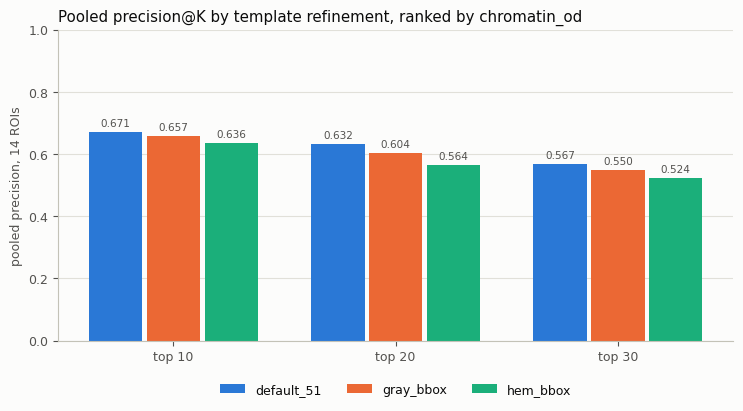

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SURFACE, INK, INK_2, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
COND_COLORS = {'default_51': '#2a78d6', 'gray_bbox': '#eb6834', 'hem_bbox': '#1baf7a'}  # reference categorical slots 1-3
OUTCOME_COLORS = {'wins': '#2a78d6', 'losses': '#e34948', 'ties': '#c3c2b7'}
DIVERGING = LinearSegmentedColormap.from_list('red_gray_blue', ['#e34948', '#f0efec', '#2a78d6'])
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE, 'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK, 'xtick.color': INK_2, 'ytick.color': INK_2, 'text.color': INK, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 9})

# Figure 1 -- pooled precision per condition at each K
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(BUDGETS))
width = 0.24
for i, condition in enumerate(CONDITIONS):
    vals = SUMMARY[SUMMARY['condition'] == condition].set_index('K').loc[list(BUDGETS), 'precision_pooled'].to_numpy()
    bars = ax.bar(x + (i - 1) * (width + 0.02), vals, width, color=COND_COLORS[condition], label=condition, zorder=2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, color=INK_2)
ax.set_xticks(x)
ax.set_xticklabels([f'top {k}' for k in BUDGETS])
ax.set_ylim(0, 1)
ax.set_ylabel('pooled precision, 14 ROIs')
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_title(f'Pooled precision@K by template refinement, ranked by {RANK_KEY}', loc='left')
fig.tight_layout()
fig.savefig(f'{FIG_STEM}_pooled_precision.png', dpi=150, bbox_inches='tight')
plt.show()

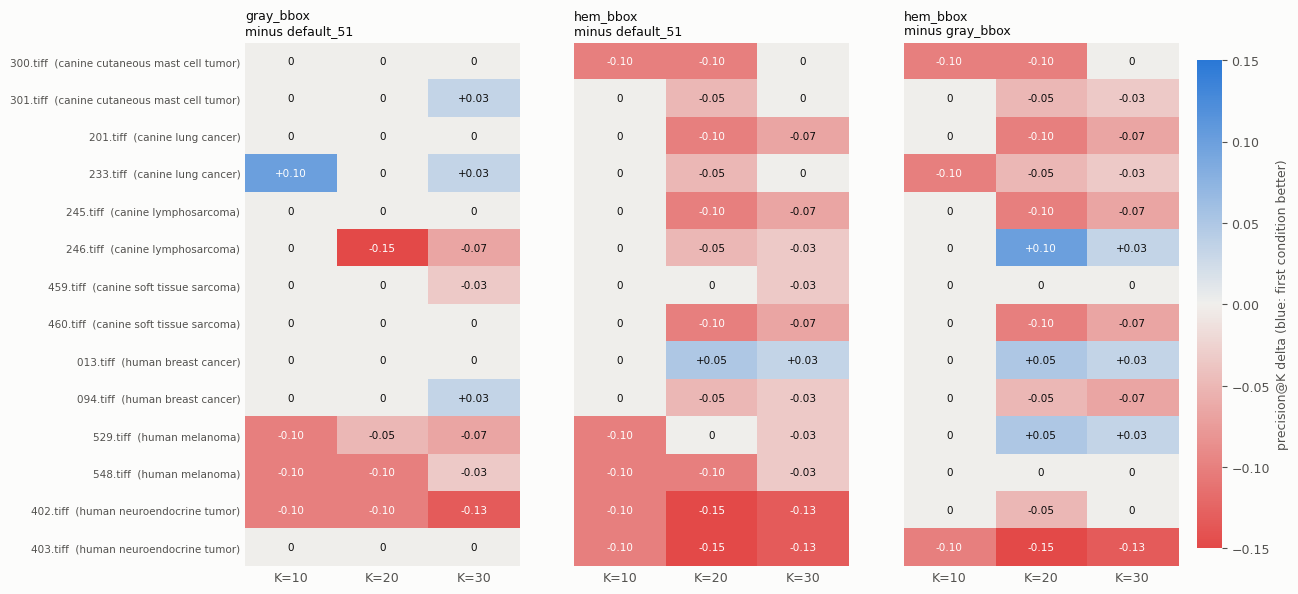

In [15]:
# Figure 2 -- per-ROI precision deltas, one panel per pair, shared colour scale
lim = max(float(DELTA_PER_ROI['delta_precision'].abs().max()), 0.05)
fig, axes = plt.subplots(1, len(PAIRS), figsize=(4.2 * len(PAIRS), 6.8), sharey=True)
for ax, (a, b) in zip(axes, PAIRS):
    pair = f'{a} - {b}'
    mat = DELTA_PER_ROI[DELTA_PER_ROI['pair'] == pair].pivot(index='file_name', columns='K', values='delta_precision').loc[ROI_ORDER, list(BUDGETS)].to_numpy()
    im = ax.imshow(mat, cmap=DIVERGING, vmin=-lim, vmax=lim, aspect='auto')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, '0' if mat[i, j] == 0 else f'{mat[i, j]:+.2f}', ha='center', va='center', fontsize=7.5, color=INK if abs(mat[i, j]) < 0.6 * lim else '#ffffff')
    ax.set_xticks(range(len(BUDGETS)))
    ax.set_xticklabels([f'K={k}' for k in BUDGETS])
    ax.set_yticks(range(len(ROI_ORDER)))
    ax.set_yticklabels([f"{fn}  ({CLICKS.loc[fn, 'domain']})" for fn in ROI_ORDER], fontsize=7.5)
    ax.tick_params(length=0)
    for side in ('left', 'bottom'):
        ax.spines[side].set_visible(False)
    ax.set_title(f'{a}\nminus {b}', loc='left', fontsize=9)
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label('precision@K delta (blue: first condition better)', color=INK_2)
cbar.outline.set_visible(False)
fig.savefig(f'{FIG_STEM}_roi_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

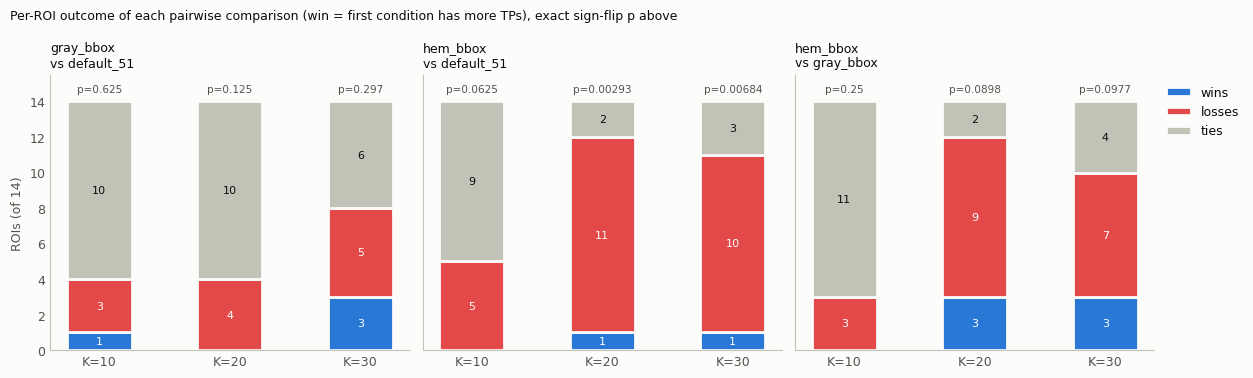

In [16]:
# Figure 3 -- wins / losses / ties per pair, per K
fig, axes = plt.subplots(1, len(PAIRS), figsize=(4.2 * len(PAIRS), 3.8), sharey=True)
x = np.arange(len(BUDGETS))
for ax, (a, b) in zip(axes, PAIRS):
    sub = DELTA_STATS[DELTA_STATS['pair'] == f'{a} - {b}'].set_index('K').loc[list(BUDGETS)]
    bottom = np.zeros(len(BUDGETS))
    for part in ('wins', 'losses', 'ties'):
        heights = sub[part].to_numpy()
        ax.bar(x, heights, 0.5, bottom=bottom, color=OUTCOME_COLORS[part], edgecolor=SURFACE, linewidth=2, label=part, zorder=2)
        for xi, h, b0 in zip(x, heights, bottom):
            if h > 0:
                ax.text(xi, b0 + h / 2, str(int(h)), ha='center', va='center', fontsize=8, color='#ffffff' if part != 'ties' else INK)
        bottom = bottom + heights
    for xi, p in zip(x, sub['exact_p']):
        ax.text(xi, 14.4, f'p={p:.3g}', ha='center', va='bottom', fontsize=7.5, color=INK_2)
    ax.set_xticks(x)
    ax.set_xticklabels([f'K={k}' for k in BUDGETS])
    ax.set_ylim(0, 15.5)
    ax.set_title(f'{a}\nvs {b}', loc='left', fontsize=9)
    ax.tick_params(length=0)
axes[0].set_ylabel('ROIs (of 14)')
axes[-1].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.0, 1.0))
fig.suptitle('Per-ROI outcome of each pairwise comparison (win = first condition has more TPs), exact sign-flip p above', fontsize=9, x=0.01, ha='left')
fig.tight_layout()
fig.savefig(f'{FIG_STEM}_win_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## Closing summary

Every number below comes from the cells above. Every check passed:
- the D9 cap bound on 42/42 runs;
- every K was fully delivered;
- no candidate survived within one match radius of the click (42/42);
- all three reproduction gates: the 14 clicks match the reference notebook's, both Otsu conditions
  reproduce its `chromatin_od` numbers on 28/28 rows, and `default_51` returns the identical top-30
  list wherever its template is the same pixels as `gray_bbox`'s.

An independent audit (`Research Logs/2026-09-16-bbox-refinement-three-way-chromatin-od-audit.md`)
re-derived all 42 top-30 lists and every TP count from the pixels and the annotation JSON, without
`midog_utils`, and found 0 divergences.

**How TPs and FPs are counted.** Detections are matched to ground truth greedily, best rank first,
each claiming the nearest unclaimed annotation within 7.5 um (29.6-33.1 px per ROI). A detection
that claims a mitotic annotation (category 1) is a TP. One that claims a look-alike (category 2) or
nothing is an FP. The clicked annotation is removed from the ground truth. The audit checked this
convention against alternatives, and TP counts were identical in all 126 (run, K) cells under each
of:
- optimal (Hungarian) matching instead of greedy;
- matching against mitoses only;
- moving the radius by 1 px either way.

No top-30 detection had both a mitosis and a look-alike within the radius, and no other annotation
lies within one radius of any click.

**The plain answer.** Ranked by `chromatin_od`, pooled precision falls in the same order at every
budget: `default_51` > `gray_bbox` > `hem_bbox`.

| K | `default_51` | `gray_bbox` | `hem_bbox` |
|---|---|---|---|
| 10 | 0.671 | 0.657 | 0.636 |
| 20 | 0.632 | 0.604 | 0.564 |
| 30 | 0.567 | 0.550 | 0.524 |

Neither Otsu refinement beats the plain 51 px box at any K on these 14 clicks.

**`hem_bbox` vs. `default_51` is the one contrast that resolves. It survives excluding contested
mitoses, but not counting them as false positives.**
- *Size:* tightening on `hematoxylin_od` costs 3.6 / 6.8 / 4.3 points of precision at K = 10 / 20 / 30.
- *Per ROI:* it loses on 5 / 11 / 10 ROIs and wins on 0 / 1 / 1 (the one win is `013.tiff`).
- *Significance:* exact sign-flip p = 0.0625 / 0.0029 / 0.0068. Holm-adjusted over all 9 tests,
  that is 0.44 / 0.026 / 0.055, so K = 20 is resolved and K = 30 just misses. At K = 10 only 5 ROIs
  differ, so the smallest p the test could return is 0.0625.
- *The caveat:* about a quarter (22.5-25.5%) of top-K TPs are contested mitoses (at least one
  reader didn't vote mitotic), evenly across conditions. Excluding them from both numerator and denominator keeps the
  result (Holm p 0.029 at K = 20 and at K = 30). Counting them as false positives does not
  (p = 0.064 / 0.037, Holm 0.52 / 0.33). The direction stays negative at every K under all three
  rules.

**`gray_bbox` vs. `default_51` is not resolved, and at K = 10 and 20 it cannot be.**
- *Size:* -1.4 / -2.9 / -1.7 points.
- *Per ROI:* ties on 10 / 10 / 6 ROIs, losses on 3 / 4 / 5, wins on 1 / 0 / 3 (p = 0.625 / 0.125 /
  0.297). With only 4 non-tied ROIs at K = 10 and 20, the smallest attainable p is 0.125.
- *Which ROIs:* it loses at some K on `246`, `402`, `459`, `529` and `548`, and wins at some K on
  `094`, `233` and `301`.
- *The ties are partly by construction.* On `245.tiff` (0 px offset) and `201.tiff` (0.5 px, which
  `read_padded_patch` rounds to the same pixel) the template is identical to `default_51`'s, and so
  is the list. `403.tiff` is the only real same-size centring shift (2 px): its top-30 list changes
  completely, but its TP counts at K = 10/20/30 don't. That is one ROI, so it says nothing general
  about centring.

**`hem_bbox` vs. `gray_bbox` reproduces the reference notebook exactly.** -2.1 / -3.9 / -2.6 points;
wins/losses/ties 0/3/11, 3/9/2 and 3/7/4; p = 0.25 / 0.090 / 0.098 (Holm 0.75 / 0.54 / 0.54).
Consistently negative, not resolved.

**Worst ROI.** `245.tiff` is the worst ROI under every condition at every K (tied with `529.tiff` for
`gray_bbox` at K = 30). `hem_bbox` pulls it from 0.20 down to 0.10 at K = 20, and from 0.23 to 0.17
at K = 30. `default_51` and `gray_bbox` are identical there by construction.

**An observation, not a mechanism.** Precision drops in the same order as median template size
(51 -> 40 -> 28 px). Size is not isolated here, though: each Otsu condition also changes the
template centre (median offset 2.5 px gray, 3.5 px hem) and which pixels count as the object. With
three conditions and no size-matched control, this ordering is not a dose-response.

**What the ties are.**
- *K = 10:* all three pairs tie on 9-11 of 14 ROIs, whatever the size gap between their templates
  (mean 9.9-21.7 px). On ROIs where the templates differ, the top-10 lists share only 1-2 exact
  candidate coordinates in total, yet find 5.2-6.8 of the same mitoses per ROI on average. The lists
  differ point by point but converge on the same mitotic figures, which is the reading the reference
  notebook now gives for its own K = 10 ties.
- *K = 20:* ties don't follow template size either. `gray_bbox - default_51` (mean gap 11.9 px) ties
  on 10 ROIs, while `hem_bbox - default_51` (21.7 px) and `hem_bbox - gray_bbox` (9.9 px, the
  smallest gap) each tie on only 2. What drives the tie count past K = 10 is not established here.

**Caveats.**
- *One click per ROI* (`seed_index = 0`). The seed-0 favourability concern in this repo is about
  `chromatin_od` vs. `tm_score`, not about conditions compared under one fixed ranker. It is still a
  single draw, and D5's bar (5 seeds x 14 ROIs, ROI-clustered paired delta) is not met. That is not
  enough to change D8 on its own.
- *The click is the joint gate's click, not each condition's own production click* (Table A,
  `refused_draws`):
  - Drawn alone, `default_51` would have clicked a different annotation on `013`, `245`, `300` and
    `403`.
  - Production `gray_bbox` (gray gate alone) would also have clicked differently on `013`, `245` and
    `300`, where only the `hematoxylin_od` gate refused the first draw. That includes `245`, the
    worst ROI.
  - On a click either gate refuses, at least one tightened condition doesn't exist, so the
    three-way comparison isn't defined there.
- *`chromatin_od` ranking only.* Nothing here carries over to `tm_score`. D9's `MAX_PEAKS = 100` was
  also validated with `tm_score` ranking, not `chromatin_od`.
- *K <= 30, 14 ROIs, 2 per domain.* Domain-level numbers move in steps of 1/(2K) and are
  descriptive only.

In [17]:
print(f'notebook ran in {time.time() - NB_T0:.0f}s')

notebook ran in 217s
